In [1]:
%pip install factor_analyzer

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import sklearn as skl
import duckdb as ddb
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import prince        #%pip install prince
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"
import plotly.express as px



#ANALISI FATTORIALE
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo


#ANOVA
from scipy.stats import f_oneway


#TEST DI TUKEY
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [4]:
df = pd.read_csv(r"C:\Users\valerio.fumasoli\Desktop\DISCRIMINANTE\ospedali.csv")

In [5]:
display(df)

,ID,Nominativo,Brand,Età,Sesso,Titolo_Studio,Professionalità_Medici,Competenza_Infermieristica,Efficacia_Cure,Comunicazione_Medici,Comfort_Stanze,Pulizia_Ambienti,Qualità_Cibo,Tempi_Attesa,Facilità_Prenotazione,Efficienza_Amministrativa,Soddisfazione_Globale,Disponibilità_Raccomandare
0,1,Lorenzo Lombardi,Policlinico Città Vecchia,35,M,Diploma,4,5,2,4,3,2,4,5,5,4,31.1,3.5
1,2,Nicola Conti,Policlinico Nord Italia,32,M,Licenza media,9,10,9,8,6,5,7,9,8,10,84.5,8.9
2,3,Alessandro Leone,Clinica Villa Aurora,51,M,Post-laurea,6,5,8,6,7,4,6,9,7,9,58.1,7.7
3,4,Riccardo Lombardi,Clinica Villa Serena,38,F,Post-laurea,8,9,9,7,8,7,6,9,7,8,78.5,6.9
4,5,Davide Colombo,Ospedale Santa Lucia,40,F,Diploma,7,8,6,6,6,7,5,7,7,7,52.8,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,2196,Nicola Moretti,Clinica Villa Serena,71,F,Diploma,6,6,6,5,9,9,10,5,6,5,73.6,6.2
2196,2197,Luca Costa,Policlinico Sant'Anna,52,M,Post-laurea,7,5,9,6,8,9,8,4,5,6,76.2,8.6
2197,2198,Roberta Marino,Policlinico Città Vecchia,49,F,Diploma,6,4,5,7,3,4,4,4,4,2,36.1,4.5
2198,2199,Elena Conti,Ospedale Regina Margherita,61,F,Post-laurea,6,6,9,6,10,9,9,7,6,10,71.7,6.0


In [6]:
df.rename(columns={'Brand':'Struttura'}, inplace=True)

In [7]:
df.columns

Index(['ID', 'Nominativo', 'Struttura', 'Età', 'Sesso', 'Titolo_Studio',
       'Professionalità_Medici', 'Competenza_Infermieristica',
       'Efficacia_Cure', 'Comunicazione_Medici', 'Comfort_Stanze',
       'Pulizia_Ambienti', 'Qualità_Cibo', 'Tempi_Attesa',
       'Facilità_Prenotazione', 'Efficienza_Amministrativa',
       'Soddisfazione_Globale', 'Disponibilità_Raccomandare'],
      dtype='str')

**EDA**

In [8]:
display(df.select_dtypes(include="number").describe(), df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          2200 non-null   int64  
 1   Nominativo                  2200 non-null   str    
 2   Struttura                   2200 non-null   str    
 3   Età                         2200 non-null   int64  
 4   Sesso                       2200 non-null   str    
 5   Titolo_Studio               2200 non-null   str    
 6   Professionalità_Medici      2200 non-null   int64  
 7   Competenza_Infermieristica  2200 non-null   int64  
 8   Efficacia_Cure              2200 non-null   int64  
 9   Comunicazione_Medici        2200 non-null   int64  
 10  Comfort_Stanze              2200 non-null   int64  
 11  Pulizia_Ambienti            2200 non-null   int64  
 12  Qualità_Cibo                2200 non-null   int64  
 13  Tempi_Attesa                2200 non-null   

,ID,Età,Professionalità_Medici,Competenza_Infermieristica,Efficacia_Cure,Comunicazione_Medici,Comfort_Stanze,Pulizia_Ambienti,Qualità_Cibo,Tempi_Attesa,Facilità_Prenotazione,Efficienza_Amministrativa,Soddisfazione_Globale,Disponibilità_Raccomandare
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,1100.500000,52.095000,6.530000,6.444545,6.559091,6.266364,6.111364,6.315455,5.798182,5.640000,5.922273,5.977727,61.448091,6.092682
std,635.229617,15.605603,2.221686,2.132410,2.315921,1.913775,2.251745,2.304974,1.962170,2.290705,2.137573,2.315292,14.941356,1.742082
min,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.300000,0.400000
25%,550.750000,41.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,51.400000,4.900000
50%,1100.500000,52.000000,7.000000,6.000000,7.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,62.300000,6.100000
75%,1650.250000,62.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,7.000000,7.000000,7.000000,8.000000,72.325000,7.300000
max,2200.000000,92.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,10.000000


None

*GROUPBY*

<Axes: xlabel='Struttura'>

Struttura                   Sesso
Clinica Villa Aurora        M        0.547059
                            F        0.452941
Clinica Villa Serena        F        0.537383
                            M        0.462617
Ospedale Regina Margherita  M        0.527094
                            F        0.472906
Ospedale San Bernardo       F        0.560606
                            M        0.439394
Ospedale San Giorgio        F        0.536232
                            M        0.463768
Ospedale Santa Chiara       F        0.581197
                            M        0.418803
Ospedale Santa Lucia        M        0.506173
                            F        0.493827
Policlinico Città Vecchia   F        0.525424
                            M        0.474576
Policlinico Nord Italia     F        0.534884
                            M        0.465116
Policlinico Sant'Anna       F        0.506329
                            M        0.493671
Name: proportion, dtype: float64

Struttura                   Sesso
Clinica Villa Aurora        M         93
                            F         77
Clinica Villa Serena        F        115
                            M         99
Ospedale Regina Margherita  M        107
                            F         96
Ospedale San Bernardo       F        111
                            M         87
Ospedale San Giorgio        F        111
                            M         96
Ospedale Santa Chiara       F        136
                            M         98
Ospedale Santa Lucia        M        123
                            F        120
Policlinico Città Vecchia   F        124
                            M        112
Policlinico Nord Italia     F        138
                            M        120
Policlinico Sant'Anna       F        120
                            M        117
Name: count, dtype: int64

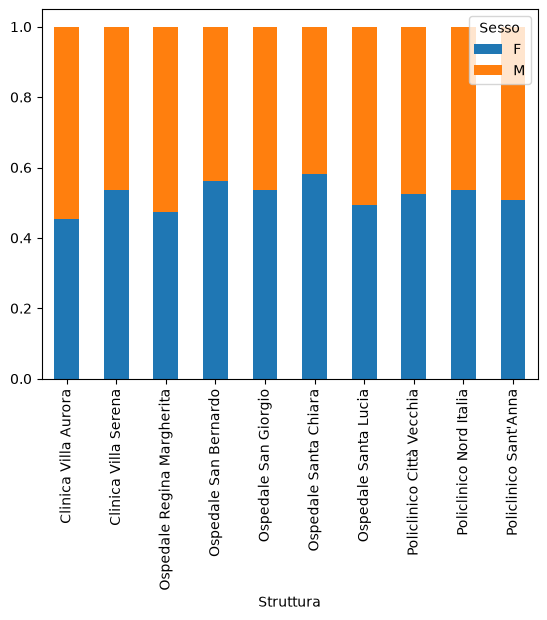

In [9]:
display(df.groupby('Struttura')['Sesso'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True))
display((df.groupby('Struttura')['Sesso'].value_counts(normalize=True)), df.groupby('Struttura')['Sesso'].value_counts())

In [10]:
df.columns

Index(['ID', 'Nominativo', 'Struttura', 'Età', 'Sesso', 'Titolo_Studio',
       'Professionalità_Medici', 'Competenza_Infermieristica',
       'Efficacia_Cure', 'Comunicazione_Medici', 'Comfort_Stanze',
       'Pulizia_Ambienti', 'Qualità_Cibo', 'Tempi_Attesa',
       'Facilità_Prenotazione', 'Efficienza_Amministrativa',
       'Soddisfazione_Globale', 'Disponibilità_Raccomandare'],
      dtype='str')

In [11]:
df

,ID,Nominativo,Struttura,Età,Sesso,Titolo_Studio,Professionalità_Medici,Competenza_Infermieristica,Efficacia_Cure,Comunicazione_Medici,Comfort_Stanze,Pulizia_Ambienti,Qualità_Cibo,Tempi_Attesa,Facilità_Prenotazione,Efficienza_Amministrativa,Soddisfazione_Globale,Disponibilità_Raccomandare
0,1,Lorenzo Lombardi,Policlinico Città Vecchia,35,M,Diploma,4,5,2,4,3,2,4,5,5,4,31.1,3.5
1,2,Nicola Conti,Policlinico Nord Italia,32,M,Licenza media,9,10,9,8,6,5,7,9,8,10,84.5,8.9
2,3,Alessandro Leone,Clinica Villa Aurora,51,M,Post-laurea,6,5,8,6,7,4,6,9,7,9,58.1,7.7
3,4,Riccardo Lombardi,Clinica Villa Serena,38,F,Post-laurea,8,9,9,7,8,7,6,9,7,8,78.5,6.9
4,5,Davide Colombo,Ospedale Santa Lucia,40,F,Diploma,7,8,6,6,6,7,5,7,7,7,52.8,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,2196,Nicola Moretti,Clinica Villa Serena,71,F,Diploma,6,6,6,5,9,9,10,5,6,5,73.6,6.2
2196,2197,Luca Costa,Policlinico Sant'Anna,52,M,Post-laurea,7,5,9,6,8,9,8,4,5,6,76.2,8.6
2197,2198,Roberta Marino,Policlinico Città Vecchia,49,F,Diploma,6,4,5,7,3,4,4,4,4,2,36.1,4.5
2198,2199,Elena Conti,Ospedale Regina Margherita,61,F,Post-laurea,6,6,9,6,10,9,9,7,6,10,71.7,6.0


focus: età rispondente

In [12]:
tab = df['Età'].value_counts().sort_index().to_frame("freq_assoluta")
tab["freq_cumulata"] = tab["freq_assoluta"].cumsum()
tab["freq_relativa"] = tab["freq_assoluta"] / tab["freq_assoluta"].sum()
tab["freq_rel_cumulata"] = tab["freq_relativa"].cumsum()*100
display(tab)

,freq_assoluta,freq_cumulata,freq_relativa,freq_rel_cumulata
Età,,,,
18,42,42,0.019091,1.909091
19,3,45,0.001364,2.045455
20,10,55,0.004545,2.500000
21,4,59,0.001818,2.681818
22,13,72,0.005909,3.272727
...,...,...,...,...
88,5,2172,0.002273,98.727273
89,2,2174,0.000909,98.818182
90,2,2176,0.000909,98.909091


*2 metodi per classificare*

In [13]:
#APPLY + LAMBDA
df['eta_cl'] = df['Età'].apply(lambda x : 'under 18' if x < 18 else ('18-30' if x >= 18 and x <= 30 else('31 - 50' if x >= 31 and x <= 50 else('51 - 70' if x >= 51 and x <= 70 else('over 70' if x >= 71 else 'NA')))))

In [14]:
#METODO PANDAS.CUT 
df['eta_cl_2'] = pd.cut(df['Età'], bins=[0, 18, 30, 50, 70, np.inf], labels=['under 18', '18-30', '31-50', '51-70', 'over 70'], right=False)

In [15]:
display(df[['eta_cl', 'eta_cl_2']].head(10))

,eta_cl,eta_cl_2
0,31 - 50,31-50
1,31 - 50,31-50
2,51 - 70,51-70
3,31 - 50,31-50
4,31 - 50,31-50
5,31 - 50,31-50
6,51 - 70,51-70
7,31 - 50,31-50
8,31 - 50,31-50
9,51 - 70,51-70


*creazione tab in dataframe pandas*

In [16]:
classi = pd.cut(df["Età"], bins=[0, 18, 30, 50, 70, 100])
tab = classi.value_counts().sort_index().to_frame("freq_assoluta")
tab["freq_cumulata"] = tab["freq_assoluta"].cumsum()
display(tab)

,freq_assoluta,freq_cumulata
Età,,
"(0, 18]",42,42
"(18, 30]",153,195
"(30, 50]",805,1000
"(50, 70]",937,1937
"(70, 100]",263,2200


In [17]:
group = df.groupby('eta_cl')['Sesso'].value_counts(normalize=True)
display(group)

eta_cl   Sesso
18-30    F        0.507692
         M        0.492308
31 - 50  M        0.511801
         F        0.488199
51 - 70  F        0.541089
         M        0.458911
over 70  F        0.566540
         M        0.433460
Name: proportion, dtype: float64

plot direttamente della series 'group'

<Axes: xlabel='eta_cl,Sesso'>

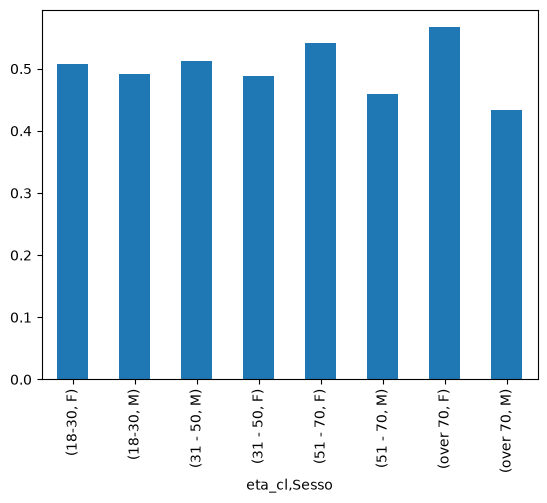

In [18]:
display(group.plot(kind='bar', stacked=True))

*metodo alternativo*

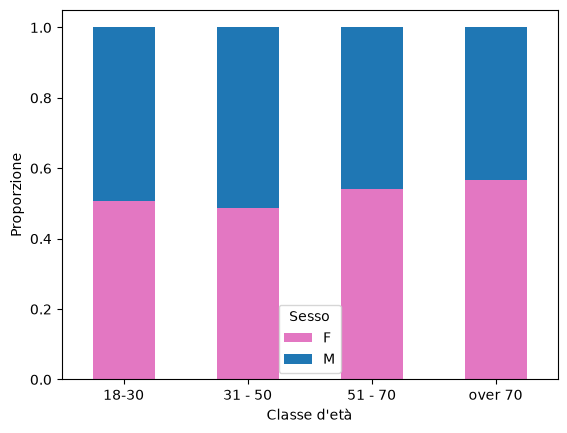

In [19]:
ax = group.unstack("Sesso").plot(kind="bar", stacked=True, color=["#e377c2", "#1f77b4"])
ax.set_xlabel("Classe d'età")
ax.set_ylabel("Proporzione")
plt.xticks(rotation=0)
plt.show()

*ANALISI FATTORIALE*

In [20]:
df.columns

Index(['ID', 'Nominativo', 'Struttura', 'Età', 'Sesso', 'Titolo_Studio',
       'Professionalità_Medici', 'Competenza_Infermieristica',
       'Efficacia_Cure', 'Comunicazione_Medici', 'Comfort_Stanze',
       'Pulizia_Ambienti', 'Qualità_Cibo', 'Tempi_Attesa',
       'Facilità_Prenotazione', 'Efficienza_Amministrativa',
       'Soddisfazione_Globale', 'Disponibilità_Raccomandare', 'eta_cl',
       'eta_cl_2'],
      dtype='str')

*Analisi di correlazione*

In [21]:
#item_cols = [col for col in df.columns if col.startswith("item")] #SE AVESSERO UNA SIMILIRITÀ NEL NOME, ALTRIMENTI SI POSSONO ELENCARE MANUALMENTE
item_cols = ['Professionalità_Medici', 'Competenza_Infermieristica',
       'Efficacia_Cure', 'Comunicazione_Medici', 'Comfort_Stanze',
       'Pulizia_Ambienti', 'Qualità_Cibo', 'Tempi_Attesa',
       'Facilità_Prenotazione', 'Efficienza_Amministrativa',
       'Soddisfazione_Globale', 'Disponibilità_Raccomandare']

corr = df[item_cols].corr()
corr_mask = corr.where(np.tril(np.ones(corr.shape, dtype=bool)))  # solo triangolo inferiore

fig = px.imshow(corr_mask, text_auto=".2f", color_continuous_scale="RdBu_r",
                zmin=-1, zmax=1, template="plotly_dark",
                title="Matrice di correlazione tra gli item")
fig.update_layout(width=900, height=800)
fig.update_xaxes(tickangle=45)
fig.show()

- Test di Bartlett: verifica se gli item sono correlati tra loro (ipotesi nulla: matrice di correlazione = identità, cioè nessuna correlazione). Se p < 0.05 gli item sono abbastanza correlati e ha senso fare l'analisi fattoriale.

- KMO: misura quanta parte delle correlazioni tra item è dovuta a fattori comuni, con valori da 0 a 1. Sotto 0.5 è inaccettabile, 0.6-0.7 è mediocre, 0.7-0.8 buono e oltre 0.8 ottimo.

In [22]:
items = df[item_cols].dropna()
chi2, p = calculate_bartlett_sphericity(items)
kmo_item, kmo_tot = calculate_kmo(items)
print(f"Bartlett p = {p:.4f}, KMO = {kmo_tot:.2f}")

Bartlett p = 0.0000, KMO = 0.89


gli indici ci restituiscono ottimi risultati in linea con i requisiti minimi per la costruzione di fattori latenti tra gli items

Criteri classici (per scegliere quanti fattori estrarre):

- Fattori con autovalore > 1 (regola di Kaiser): conta quanti punti dello scree plot stanno sopra la linea rossa; quello è il numero di fattori da tenere.
l'autovalore indica quanta varianza dei dati spiega un fattore, misurata in "numero di item". Siccome gli item vengono standardizzati, ognuno ha varianza pari a 1, quindi con i tuoi 12 item la varianza totale è 12. Se il primo fattore ha autovalore 4.5, vuol dire che da solo riassume l'informazione di circa 4 item e mezzo (4.5/12 = 37,5% della varianza totale). -> un autovalore < 1 spiega meno varianza di un singolo item quindi non ha senso selezionarlo. -> un fattore che spiega meno di un item non sta riassumendo nulla ( il mio obiettivo è quello di selezioanare e poi scegliere fattori che riassumono l'info di piu item (varianza spiegata))
- Gomito dello scree plot: cerca il punto in cui la curva smette di scendere ripidamente e diventa piatta; tieni i fattori prima del gomito.

Se i due criteri danno numeri diversi (es. 3 e 4), stima entrambe le soluzioni e scegli quella più facile da interpretare.

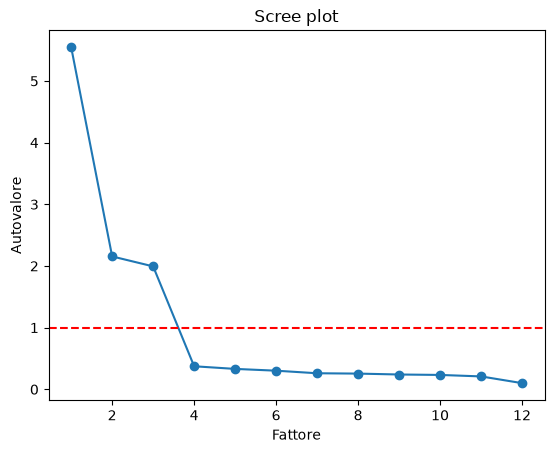

In [23]:
fa = FactorAnalyzer(rotation=None) #è l'oggetto modello creato con FactorAnalyzer, una specie di "contenitore" in cui imposti le opzioni (numero di fattori, rotazione). 
#Dopo il fit, dentro ci sono tutti i risultati (fa.loadings_, comunalità, varianza spiegata).
fa.fit(items)
autovalori, _ = fa.get_eigenvalues()

plt.plot(range(1, len(autovalori) + 1), autovalori, marker="o")
plt.axhline(1, color="red", linestyle="--")
plt.xlabel("Fattore"); plt.ylabel("Autovalore"); plt.title("Scree plot")
plt.show()

3 fattori riassumono gran parte dell'informazione contenuta nei 12 item. Seguo la regola del gomito e di keiser (che taglia a 1) e decido di effettuare un analisi fattoriale a 3 dimensioni.

NB: il primo fattore è molto piu grande degli altri (da solo spiega circa il 46% d varianza)

*CALCOLO DEI LOADINGS* -> è la correlazione tra ogni item e ogni fattore, da -1 a 1. Un loading alto (es. 0.8) significa che quell'item "appartiene" fortemente a quel fattore. Si calcolano scomponendo la matrice di correlazione tra gli item.

In [24]:
n = 3   # prova anche 4
fa = FactorAnalyzer(n_factors=n, rotation="varimax") 
#LA ROTAZIONE VARIMAX "gira" gli assi dei fattori in modo che ogni item carichi molto su un fattore e poco sugli altri, rendendo la soluzione più facile da interpretare. 
#Non cambia quanta varianza viene spiegata in totale, solo come viene distribuita. Varimax mantiene i fattori non correlati tra loro.
fa.fit(items) 
#il modello "impara" dai dati: legge gli item, calcola le correlazioni ed estrae i fattori. Prima del fit fa è vuoto; dopo contiene tutti i risultati stimati.

loadings = pd.DataFrame(fa.loadings_, index=items.columns,
                        columns=[f"F{i+1}" for i in range(n)])
display(loadings.round(2))

,F1,F2,F3
Professionalità_Medici,0.87,0.12,0.09
Competenza_Infermieristica,0.83,0.15,0.05
Efficacia_Cure,0.88,0.10,0.04
Comunicazione_Medici,0.78,0.09,0.19
Comfort_Stanze,0.09,0.09,0.86
Pulizia_Ambienti,0.13,0.08,0.86
Qualità_Cibo,0.09,0.08,0.81
Tempi_Attesa,0.11,0.87,0.09
Facilità_Prenotazione,0.11,0.84,0.08
Efficienza_Amministrativa,0.18,0.85,0.08


I 3 fattori generati possono essere descritti nel seguente modo: (TAGLIO IL LOADING A CIRCA 0.45)

- 1: IL PRIMO FATTORE E' SPIEGATO DA ITEM CHE POSSONO ESSERE RICONDOTTI ALLA SFERA DELLA COMPETENZA PROFESSIONALE DEL PERSONALE MEDICO ED INFERMIERISTICO ED ALL'EFFICACIA DELLE CURE.

- 2: IL SECONDO FATTORE TROVA AMPIA SPIEGAZIONE IN ITEM COME TEMPI DI ATTESA, FACILITA' DI PRENOTAZIONE, EFFICIENZA AMMINISTRATIVA. POSSIAMO RICONDURLO AD UNA SFERA PURAMENTE AMMINISTRATIVA-LOGISTICA.

- 3: IL TERZO FATTORE SI PUO RICONDURRE AD ASPETTI INERENTI LA QUALITA' DELLE STRUTTURE E I RELATIVI SERVIZI. E' UN FATTORE RICONDUCIBILE AD ITEM INERENTI IL COMFORT DI STRUTTUA.

In [25]:
loadings.rename(columns={'F1':'COMPETENZA ED EFFICACIA', 'F2':'AMMINISTRAZIONE E LOGISTICA', 'F3':'COMFORT DI STRUTTURA'}, inplace=True)

In [26]:
varianza = pd.DataFrame(fa.get_factor_variance(),
                        index=["SS loadings", "% varianza", "% cumulata"],
                        columns=loadings.columns)
display(varianza.round(2))

,COMPETENZA ED EFFICACIA,AMMINISTRAZIONE E LOGISTICA,COMFORT DI STRUTTURA
SS loadings,3.57,2.72,2.65
% varianza,0.30,0.23,0.22
% cumulata,0.30,0.52,0.74


*COMUNALITA'*

La comunalità è la quota di varianza di ogni item spiegata dall'insieme dei fattori, da 0 a 1. Si calcola sommando i quadrati dei loading di quell'item su tutti i fattori. In pratica ti dice quanto bene ogni item è rappresentato dalla soluzione fattoriale: un valore di 0.77 significa che il 77% della variabilità di quell'item è catturato dai 3 fattori, il resto è specifico dell'item o errore.

In [27]:
comunalita = pd.Series(fa.get_communalities(), index=items.columns).sort_values()

fig = px.bar(comunalita, orientation="h", template="plotly_dark", text_auto=".2f",
             title="Comunalità degli item", labels={"value": "Comunalità", "index": ""})
fig.add_vline(x=0.5, line_dash="dash", line_color="orange", annotation_text="0.5 buona")
fig.add_vline(x=0.3, line_dash="dash", line_color="red", annotation_text="0.3 minima")
fig.update_layout(showlegend=False, xaxis_range=[0, 1], height=550)
fig.show()

Tutti gli item hanno una buona comunalità. la soddisfazione globale ha un punteggio di comunalità pari a 0.93, risulta essere in linea con il fatto che l'item è una variabile globale di soddisfazione e si porta dietro tutte le dimensioni dell'insieme.

In [28]:
import plotly.express as px

comunalita = pd.Series(fa.get_communalities(), index=items.columns).sort_values()

fig = px.bar(comunalita, orientation="h", template="plotly_dark", text_auto=".2f",
             title="Comunalità degli item", labels={"value": "Comunalità", "index": ""})
fig.add_vline(x=0.5, line_dash="dash", line_color="orange", annotation_text="0.5 buona")
fig.add_vline(x=0.3, line_dash="dash", line_color="red", annotation_text="0.3 minima")
fig.update_layout(showlegend=False, xaxis_range=[0, 1], height=550)
fig.show()

Punteggio fattoriale: è il valore che ogni rispondente ha su ciascun fattore, cioè la sua posizione sulla dimensione latente (es. quanto è soddisfatto del personale sanitario). Si calcola come una media pesata dei suoi voti, dove i pesi derivano dai loading. Lo ottieni co

*PUNTEGGI FATTORIALI*

Sono la stima della posizione di ogni rispondente su ciascun fattore latente, calcolata combinando i suoi voti con pesi derivati dai loading. Sono standardizzati: media 0 e deviazione standard circa 1. Un +1 significa "una deviazione standard sopra la media del campione" su quella dimensione, un -1 "una sotto"; lo 0 è il rispondente medio.

In [29]:
punteggi = pd.DataFrame(fa.transform(items),
                        index=items.index,          # stesse righe di items
                        columns=loadings.columns)   # nomi dei fattori

df = df.join(punteggi)
display(df.head())

,ID,Nominativo,Struttura,Età,Sesso,Titolo_Studio,Professionalità_Medici,Competenza_Infermieristica,Efficacia_Cure,Comunicazione_Medici,...,Tempi_Attesa,Facilità_Prenotazione,Efficienza_Amministrativa,Soddisfazione_Globale,Disponibilità_Raccomandare,eta_cl,eta_cl_2,COMPETENZA ED EFFICACIA,AMMINISTRAZIONE E LOGISTICA,COMFORT DI STRUTTURA
0,1,Lorenzo Lombardi,Policlinico Città Vecchia,35,M,Diploma,4,5,2,4,...,5,5,4,31.1,3.5,31 - 50,31-50,-1.407165,-0.378412,-1.480150
1,2,Nicola Conti,Policlinico Nord Italia,32,M,Licenza media,9,10,9,8,...,9,8,10,84.5,8.9,31 - 50,31-50,1.218168,1.453536,-0.220753
2,3,Alessandro Leone,Clinica Villa Aurora,51,M,Post-laurea,6,5,8,6,...,9,7,9,58.1,7.7,51 - 70,51-70,-0.316366,1.078394,-0.455725
3,4,Riccardo Lombardi,Clinica Villa Serena,38,F,Post-laurea,8,9,9,7,...,9,7,8,78.5,6.9,31 - 50,31-50,0.799500,0.916620,0.293187
4,5,Davide Colombo,Ospedale Santa Lucia,40,F,Diploma,7,8,6,6,...,7,7,7,52.8,5.3,31 - 50,31-50,-0.172120,0.303782,-0.338139


*CHECK RELAZIONE CATEGORIE - FATTORI*

In [30]:
str_f_1 = df.groupby("Struttura")[["COMPETENZA ED EFFICACIA", "AMMINISTRAZIONE E LOGISTICA","COMFORT DI STRUTTURA"]].mean()
display(str_f_1)

,COMPETENZA ED EFFICACIA,AMMINISTRAZIONE E LOGISTICA,COMFORT DI STRUTTURA
Struttura,,,
Clinica Villa Aurora,0.179985,-0.523348,0.622602
Clinica Villa Serena,-0.180876,0.519555,1.131873
Ospedale Regina Margherita,-0.490781,0.129619,0.941040
Ospedale San Bernardo,0.937758,-0.632054,-0.188894
Ospedale San Giorgio,-0.840885,-0.835084,-0.375402
Ospedale Santa Chiara,-0.692848,-0.162969,0.070791
Ospedale Santa Lucia,0.137113,0.939276,-0.703407
Policlinico Città Vecchia,-0.494275,-0.594750,-0.809556
Policlinico Nord Italia,0.372078,0.870973,-0.392433


*VERIFICHE DI AFFIDABILITA'*

Verifico che il numero di osservazioni per struttura sia sufficiente a garantire medie statisticamente affidabili e che la numerosità del campione sia equilibrata tra le diverse strutture.

In [31]:
display(df["Struttura"].value_counts())

Struttura
Policlinico Nord Italia       258
Ospedale Santa Lucia          243
Policlinico Sant'Anna         237
Policlinico Città Vecchia     236
Ospedale Santa Chiara         234
Clinica Villa Serena          214
Ospedale San Giorgio          207
Ospedale Regina Margherita    203
Ospedale San Bernardo         198
Clinica Villa Aurora          170
Name: count, dtype: int64

*ANOVA AD UNA VIA ("C'è almeno una differenza tra gli ospedali?)*

confronta le medie di più gruppi (qui le strutture) e verifica se le differenze tra loro sono reali o dovute al caso. È importante perché le medie da sole possono ingannare: due strutture possono sembrare diverse solo per la variabilità casuale del campione, mentre l'ANOVA ti dice se la differenza è statisticamente significativa.

Nel codice è presente il ciclo for poichè l'ANOVA si calcola su singolo ospedale, vado a confrontare le medie sui singoli ospedali con le medie complessive di tutti i rispondenti sul fattore specifico. Conviene farlo su i fattori poichè in questo modo posso considerare informazioni ridondanti (riassunte dai fattori) e non replicare 12 analisi anova su tutti gli item originali.

*NB* : Alla base di questo test inferenziale è presente la condizione che il campione debba essere rappresentativo e non distorto, altrimenti il test anche se p-value basso sarebbe inaffidabile.

In [32]:
for f in ["COMPETENZA ED EFFICACIA", "AMMINISTRAZIONE E LOGISTICA", "COMFORT DI STRUTTURA"]:
    gruppi = [g[f].dropna() for _, g in df.groupby("Struttura")]
    stat, p = f_oneway(*gruppi)
    print(f"{f}: F = {stat:.2f}, p = {p:.4f}")



#SE P < 0.05 LE STRUTTURE DIFFERISCONO SIGNIFICATIVAMENTE SU QUEL FATTORE (almeno un ospedale per quel fattore è diverso dagli altri), QUINDI LE DIFFERENZE IN TABELLA DELLE MEDIE SONO AFFIDABILI.
#F CI INDICA LA GRANDEZZA DELLA DIFFERENZA TRA I GRUPPI RISPETTO ALLA VARIABILITA' INTERNA (PIU E' ALTA PIU LE STRUTTURE SONO DISTINTE TRA LORO)

COMPETENZA ED EFFICACIA: F = 174.36, p = 0.0000
AMMINISTRAZIONE E LOGISTICA: F = 176.60, p = 0.0000
COMFORT DI STRUTTURA: F = 192.42, p = 0.0000


p-value = 0.00000 -> ci indica che la probabilità che le differenze tra ospedali siano dovute al caso è praticamente nulla.

valori F -> le differenze tra un ospedale all'altro sono circa 170-190 volte più grandi delle differenze tra i pazienti dello stesso ospedale (comfort ha la F più alta, è la dimensione su cui le strutture si distinguono di più tra loro).

- esempio: sul comfort, Villa Serena ha una media di +1.13 e Città Vecchia di -0.81. L'ANOVA ti conferma che questa distanza non è un caso dovuto ai pazienti intervistati: se intervistassi altri pazienti, ritroveresti con ogni probabilità lo stesso ordine, con Villa Serena in alto e Città Vecchia in basso.


*TEST DI TUKEY ("Quali ospedali sono diversi tra loro?")*

Confronta tutte le coppie: con 10 strutture sono 45 confronti (Sant'Anna contro San Giorgio, Sant'Anna contro Villa Serena, e così via) e per ognuno ti dice se la differenza è reale.

In [ ]:
tukey = pairwise_tukeyhsd(df["COMPETENZA ED EFFICACIA"].dropna(),
                          df.loc[df["COMPETENZA ED EFFICACIA"].notna(), "Struttura"])
print(tukey.summary())
tukey = pairwise_tukeyhsd(df["COMPETENZA ED EFFICACIA"].dropna(),
                          df.loc[df["COMPETENZA ED EFFICACIA"].notna(), "Struttura"])
print(tukey.summary())

                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                     
          group1                     group2           meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------------------
      Clinica Villa Aurora       Clinica Villa Serena  -0.3609 0.0001 -0.5999 -0.1219   True
      Clinica Villa Aurora Ospedale Regina Margherita  -0.6708    0.0 -0.9126 -0.4289   True
      Clinica Villa Aurora      Ospedale San Bernardo   0.7578    0.0  0.5145   1.001   True
      Clinica Villa Aurora       Ospedale San Giorgio  -1.0209    0.0 -1.2616 -0.7801   True
      Clinica Villa Aurora      Ospedale Santa Chiara  -0.8728    0.0 -1.1073 -0.6384   True
      Clinica Villa Aurora       Ospedale Santa Lucia  -0.0429 0.9999 -0.2755  0.1897  False
      Clinica Villa Aurora  Policlinico Città Vecchia  -0.6743    0.0 -0.9083 -0.4402   True
      Clinica Villa Aurora    Policlinico Nord Italia   0.1921 0.1964 

LA COLONNA 'REJECT' CI RESTITUISCE L'OUTPUT:
- TRUE -> C'è DIFFERENZA SULLE MEDIE
- FALSE -> NON POSSO AFFERMARE CHE SONO DIFFERENTI (GUARDANDO ANCHE L'INTERVALLO DI CONFIDENZA COSTRUITO SI PUO VERIFICARE CHE LO 0 SIA PIU' O MENO AL CENTRO DELL'INTERVALLO)